In [ ]:
# import os

# # align contigs to inputs with blast anicalc
# for i in range(0,5):
#     if os.path.exists(f'split_{i+1}/14Apr2025_genomes_oral_votu_reps.part_00{i+1}.fa.nhr'):
#         print(f'split_{i+1} already exists, skipping...')
#         continue

#     !mkdir -p split_{i+1}

#     !micromamba run -n blast makeblastdb \
#         -in /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/composite_sputum_metagenome/oral_votu_reps_split/14Apr2025_genomes_oral_votu_reps.part_00{i+1}.fa \
#         -dbtype nucl \
#         -out split_{i+1}/14Apr2025_genomes_oral_votu_reps.part_00{i+1}.fa

In [1]:
import os

for i in range(0, 25):
    for assembler in ['penguin', 'megahit', 'metaspades', 'high_kmer', 'cobra', 'coassembly']:

        j = (i % 5) + 1
        print(f'Using reference split_{j} for assembly {assembler} with split_{i} reads')

        if assembler == 'megahit':
            input_file = f'megahit/split_{i}_reads_megahit_output/final.contigs.fa'
            output = f'megahit/split_{i}_v_oral_votu_reps'
        if assembler == 'metaspades':
            input_file = f'metaspades/split_{i}_reads_metaspades_output/scaffolds.fasta'
            output = f'metaspades/split_{i}_v_oral_votu_reps'
        if assembler == 'penguin':
            input_file = f'penguin/split_{i}_reads.fasta'
            output = f'penguin/split_{i}_v_oral_votu_reps'
        if assembler == 'high_kmer':
            input_file = f'megahit/split_{i}_reads_megahit_high_kmer_output/final.contigs.fa'
            output = f'megahit/high_kmer_split_{i}_v_oral_votu_reps'
        if assembler == 'cobra':
            input_file = f"cobra/cobra_split_{i}_reads/final.contigs.new.fa"
            output = f"cobra/cobra_{i}_v_oral_votu_reps"
        if assembler == 'coassembly':
            if i > 4:
                continue
            input_file = f'megahit/split_{i}_reads_megahit_coassembly_output/final.contigs.fa'
            output = f'megahit/coassembly_split_{i}_v_oral_votu_reps'

        if os.path.exists(f'{output}.anicalc.tsv'):
            print(f'Output file {output}.anicalc.tsv already exists, skipping...')
            continue

        !seqkit seq {input_file} --min-len 2000 --out-file {input_file}.filtered.fna

        !micromamba run -n blast blastn \
            -query {input_file}.filtered.fna \
            -db split_{j}/14Apr2025_genomes_oral_votu_reps.part_00{j}.fa \
            -outfmt '6  std qlen slen' \
            -max_target_seqs 100 \
            -out {output}.blastn.tsv \
            -num_threads 8

        !micromamba run -n blast python anicalc.py \
            -i {output}.blastn.tsv \
            -o {output}.anicalc.tsv

Using reference split_1 for assembly penguin with split_0 reads
Output file penguin/split_0_v_oral_votu_reps.anicalc.tsv already exists, skipping...
Using reference split_1 for assembly megahit with split_0 reads
Output file megahit/split_0_v_oral_votu_reps.anicalc.tsv already exists, skipping...
Using reference split_1 for assembly metaspades with split_0 reads
Output file metaspades/split_0_v_oral_votu_reps.anicalc.tsv already exists, skipping...
Using reference split_1 for assembly high_kmer with split_0 reads
Output file megahit/high_kmer_split_0_v_oral_votu_reps.anicalc.tsv already exists, skipping...
Using reference split_1 for assembly cobra with split_0 reads
[WARN] you may switch on flag -g/--remove-gaps to remove spaces
Using reference split_1 for assembly coassembly with split_0 reads
Output file megahit/coassembly_split_0_v_oral_votu_reps.anicalc.tsv already exists, skipping...
Using reference split_2 for assembly penguin with split_1 reads
Output file penguin/split_1_v_ora

In [ ]:
# #count reads derived from each reference
# import gzip
# import polars as pl

# for i in range(0,25):

#     j = (i % 5) + 1
#     print(f'Using reference split_{j} with split_{i} reads')

#     if os.path.exists(f'split_{j}/split_{i}_cov.txt'):
#         print(f'Coverage file split_{j}/split_{i}_cov.txt already exists, skipping...')
#         continue

#     genome_read_counts = {}
#     with open(f'/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/composite_sputum_metagenome/oral_phage_readsim/split_{i}_reads_abundance.txt', 'r') as f:
#         for line in f.readlines():
#             genome_read_counts[line.split('\t')[0]] = 0

#     with gzip.open(f'/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/composite_sputum_metagenome/oral_phage_readsim/split_{i}_reads_R1.fastq.gz', 'rt') as f:
#         for line in f.readlines():
#             if line.startswith('@'):
#                 genome_read_counts[line.rpartition('_')[0].rpartition('_')[0][1:]] += 1

#     with gzip.open(f'/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/composite_sputum_metagenome/oral_phage_readsim/split_{i}_reads_R2.fastq.gz', 'rt') as f:
#         for line in f.readlines():
#             if line.startswith('@'):
#                 genome_read_counts[line.rpartition('_')[0].rpartition('_')[0][1:]] += 1

#     # calculate coverage for each reference
#     inphared_meta = (
#         pl.read_csv('https://millardlab-inphared.s3.climb.ac.uk/14Apr2025_data.tsv.gz', separator='\t', columns=['Accession', 'Genome Length (bp)'])
#             .filter(pl.col('Accession').is_in(genome_read_counts.keys()))
#             .with_columns(read_count=pl.col('Accession').replace_strict(genome_read_counts, return_dtype=pl.Int64))
#             .with_columns(coverage=pl.col('read_count') * 300 / pl.col('Genome Length (bp)'))
#             .rename({
#                 'Accession': 'tname',
#                 'Genome Length (bp)': 'genome_length'
#             })
#     )

#     # write out coverage file
#     inphared_meta.write_csv(f'split_{j}/split_{i}_cov.txt', separator='\t')

In [1]:
import polars as pl

raw_data_lst = []
genome_cov_lst = []
contig_cov_lst = []

for i in range(0,25):
    for assembler in ['penguin', 'megahit', 'metaspades', 'high_kmer', 'cobra', 'coassembly']:
        if assembler == 'megahit':
            anicalc = pl.read_csv(f'megahit/split_{i}_v_oral_votu_reps.anicalc.tsv', separator='\t')
        if assembler == 'metaspades':
            anicalc = pl.read_csv(f'metaspades/split_{i}_v_oral_votu_reps.anicalc.tsv', separator='\t')
        if assembler == 'penguin':
            anicalc = pl.read_csv(f'penguin/split_{i}_v_oral_votu_reps.anicalc.tsv', separator='\t')
        if assembler == 'high_kmer':
            anicalc = pl.read_csv(f'megahit/high_kmer_split_{i}_v_oral_votu_reps.anicalc.tsv', separator='\t')
        if assembler == 'coassembly':
            if i > 4:
                continue
            anicalc = pl.read_csv(f'megahit/coassembly_split_{i}_v_oral_votu_reps.anicalc.tsv', separator='\t')
        if assembler == 'cobra':
            anicalc = pl.read_csv(f"cobra/cobra_{i}_v_oral_votu_reps.anicalc.tsv", separator='\t')
        

        if i < 5:
            j = i + 1
        else:
            j = (i % 5) + 1
        print(f'Using reference split_{j} with split_{i} reads')

        # read coverage file
        inphared_meta = pl.read_csv(f'split_{j}/split_{i}_cov.txt', separator='\t')

        raw_data_lst.append(
            anicalc
                .with_columns([
                    (pl.col('qname').cast(pl.String)),
                    (pl.lit(f'{assembler}').alias('assembler')),
                    (pl.lit(f'{i}').alias('split')),
                    (pl.lit(f'{j}').alias('group')),
                    (pl.col('tcov').fill_nan(0))
                ])
        )

        # keep top alignment for each contig
        best_contig_hit = (
            anicalc
                .with_columns([
                    (pl.col('qname').cast(pl.String)),
                    (pl.lit(f'{assembler}').alias('assembler')),
                    (pl.lit(f'{i}').alias('split')),
                    (pl.lit(f'{j}').alias('group')),
                    (pl.col('tcov').fill_nan(0)),
                    ((pl.col('pid') * pl.col('qcov')/100).alias('qani'))
                ])
                .sort(pl.col('qani'), descending=True)
                .group_by(pl.col('qname'), maintain_order=True).first()
        )

        contig_cov_lst.append(best_contig_hit)

        # identify best query for each reference
        best_ref_hit = (
            best_contig_hit
                .filter(pl.col('pid') >= 95)
                .with_columns([
                    (pl.col('pid') * pl.col('tcov')/100).alias('tani')
                ])
                .sort(pl.col('tani'), descending=True)
                .group_by(pl.col('tname'), maintain_order=True).first()
        )

        # join coverage with best reference hits
        genome_cov = (
            best_ref_hit
                .join(inphared_meta, on='tname', how='full', coalesce=True)
        )

        genome_cov_lst.append(genome_cov)

# concatenate all contig coverage dataframes
raw_df = pl.concat(raw_data_lst)
contig_cov_df = pl.concat(contig_cov_lst)
genome_cov_df = pl.concat(genome_cov_lst)

Using reference split_1 with split_0 reads
Using reference split_1 with split_0 reads
Using reference split_1 with split_0 reads
Using reference split_1 with split_0 reads
Using reference split_1 with split_0 reads
Using reference split_1 with split_0 reads
Using reference split_2 with split_1 reads
Using reference split_2 with split_1 reads
Using reference split_2 with split_1 reads
Using reference split_2 with split_1 reads
Using reference split_2 with split_1 reads
Using reference split_2 with split_1 reads
Using reference split_3 with split_2 reads
Using reference split_3 with split_2 reads
Using reference split_3 with split_2 reads
Using reference split_3 with split_2 reads
Using reference split_3 with split_2 reads
Using reference split_3 with split_2 reads
Using reference split_4 with split_3 reads
Using reference split_4 with split_3 reads
Using reference split_4 with split_3 reads
Using reference split_4 with split_3 reads
Using reference split_4 with split_3 reads
Using refer

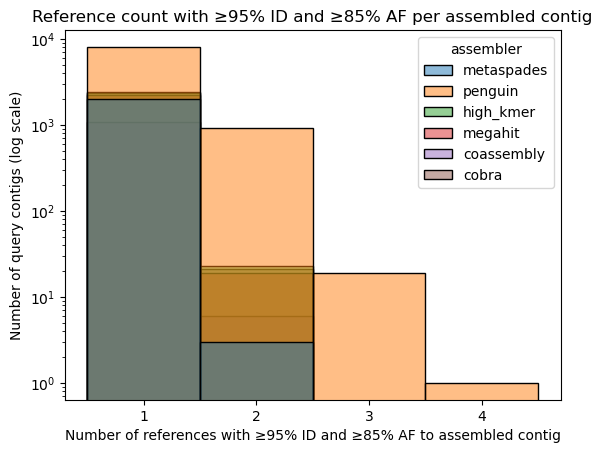

In [50]:
chimeras = (
    raw_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 85))
        .group_by(['qname', 'assembler', 'split'])
        .agg([pl.len().alias('len').cast(pl.String), pl.col('group').first().alias('group')])
)

sns.histplot(x="len", hue='assembler', data=chimeras)
plt.title('Reference count with ≥95% ID and ≥85% AF per assembled contig')
plt.yscale('log')
plt.ylabel('Number of query contigs (log scale)')
plt.xlabel('Number of references with ≥95% ID and ≥85% AF to assembled contig')
plt.show()

In [19]:
(
    raw_df
        .filter(
            ((pl.col('qname').cast(pl.String)) + '-' + (pl.col('assembler').cast(pl.String)) + '-' + (pl.col('split').cast(pl.String))).is_in(chimeric_assemblies)
        )
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 85))
        .group_by(['assembler'])
        .agg([
            pl.len().alias('len'),
            pl.col('qcov').mean().alias('mean_qcov'),
        ])
)

assembler,len,mean_qcov
str,u32,f64
"""coassembly""",12,54.076667
"""metaspades""",6,71.463333
"""penguin""",1913,89.141945
"""cobra""",42,64.470714
"""high_kmer""",46,63.94087
"""megahit""",38,63.460526


In [21]:
(
    raw_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 85))
        .group_by(['qname', 'assembler', 'split'])
        .len()
        .filter(pl.col('len') >= 2)
        .group_by('assembler').len().sort('len', descending=True)
)

assembler,len
str,u32
"""penguin""",946
"""high_kmer""",23
"""cobra""",21
"""megahit""",19
"""coassembly""",6
"""metaspades""",3


In [22]:
(
    raw_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 85) & (pl.col('qcov') >= 99))
        .group_by(['qname', 'assembler', 'split'])
        .len()
        .filter(pl.col('len') == 1)
        .group_by('assembler').len().sort('len', descending=True)
)

assembler,len
str,u32
"""penguin""",3457
"""cobra""",2020
"""high_kmer""",1970
"""megahit""",1927
"""metaspades""",1673
"""coassembly""",1032


In [ ]:
(
    raw_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 85) & (pl.col('qcov') <= ))
        .group_by(['qname', 'assembler', 'split'])
        .len()
        .filter(pl.col('len') == 1)
        .group_by('assembler').len().sort('len', descending=True)
)

assembler,len
str,u32
"""penguin""",112
"""cobra""",22
"""high_kmer""",22
"""megahit""",20
"""coassembly""",5


In [14]:
complete_genomes = (
    contig_cov_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 100))
)
hq_genomes = (
    contig_cov_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 90))
)
mq_genomes = (
    contig_cov_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') >= 50))
)
lq_genomes = (
    contig_cov_df
        .filter((pl.col('pid') >= 95) & (pl.col('tcov') < 50))
)
print("Number of high-quality genomes:", hq_genomes.unique('tname').shape[0])
print("Total number of genomes assembled:", contig_cov_df.unique('tname').shape[0])

Number of high-quality genomes: 2462
Total number of genomes assembled: 3855


In [31]:
pl.Config.set_tbl_rows(20)
# print(
#     complete_genomes.group_by(['tname', 'assembler']).len().sort(pl.col('assembler'))
#         # .group_by(pl.col('tname'), maintain_order=True).agg([pl.col('assembler'), pl.col('assembler').len().alias('len')])
#         .group_by('assembler').len().sort(pl.col('len'), descending=True)
# )
print(
    hq_genomes.group_by(['tname', 'assembler', 'group']).len().sort(pl.col('assembler'))
        # .group_by(pl.col('tname'), maintain_order=True).agg([pl.col('assembler'), pl.col('assembler').len().alias('len')])
        .group_by(['assembler', 'group']).len()
        .group_by('assembler').agg(pl.col('len').mean().alias('mean_count'))
        .sort(pl.col('mean_count'), descending=True)

)
# print(
#     mq_genomes.group_by(['tname', 'assembler']).len().sort(pl.col('assembler'))
#         # .group_by(pl.col('tname'), maintain_order=True).agg([pl.col('assembler'), pl.col('assembler').len().alias('len')])
#         .group_by('assembler').len().sort(pl.col('len'), descending=True)
# )

shape: (6, 2)
┌────────────┬────────────┐
│ assembler  ┆ mean_count │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ penguin    ┆ 415.4      │
│ high_kmer  ┆ 223.6      │
│ cobra      ┆ 216.6      │
│ coassembly ┆ 210.4      │
│ megahit    ┆ 199.8      │
│ metaspades ┆ 173.6      │
└────────────┴────────────┘


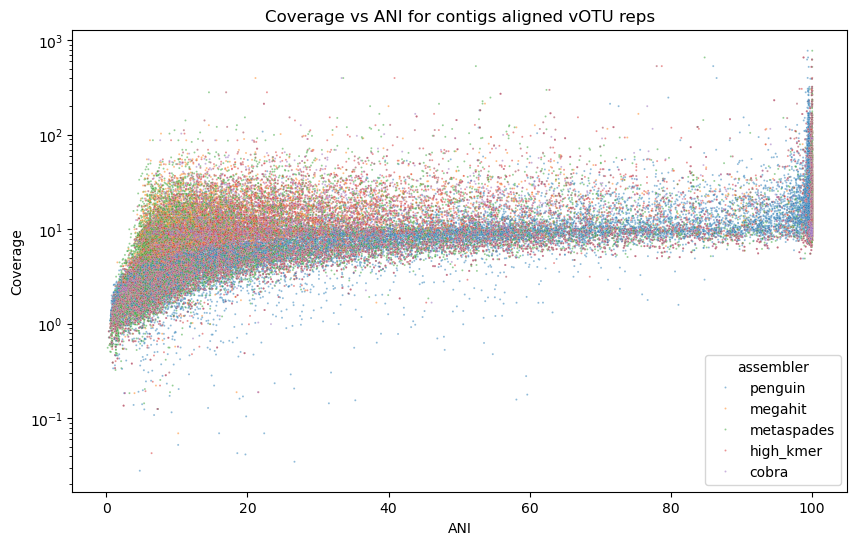

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(data=genome_cov_df.filter(~pl.col('assembler').str.contains('coassembly')), x='tani', y='coverage', alpha=0.5, s=2, hue='assembler')
plt.xlabel('ANI')
plt.ylabel('Coverage')
plt.yscale('log')
plt.title('Coverage vs ANI for contigs aligned vOTU reps')
plt.show()

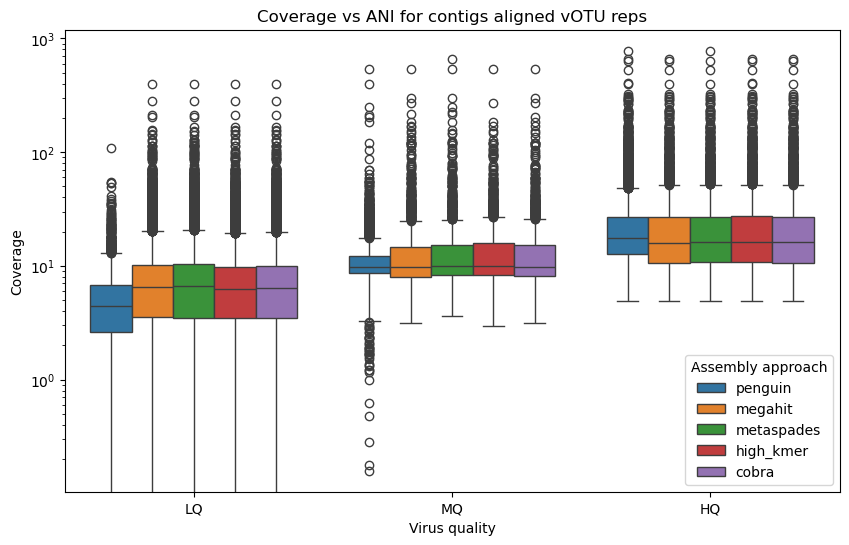

In [56]:
cov_plot_df = (
    genome_cov_df
        .with_columns([
            pl.when((pl.col('pid') >= 95) & (pl.col('tcov') >= 90)).then(pl.lit('HQ'))
                .when((pl.col('pid') >= 95) & (pl.col('tcov') >= 50)).then(pl.lit('MQ'))
                .otherwise(pl.lit('LQ')).alias('quality')
        ])
)

plt.figure(figsize=(10,6))
sns.boxplot(data=cov_plot_df.filter(~pl.col('assembler').str.contains('coassembly')), x='quality', y='coverage', hue='assembler', order=['LQ', 'MQ', 'HQ'])
plt.xlabel('Virus quality')
plt.ylabel('Coverage')
# plt.yscale('log')
plt.yscale('log')
plt.title('Coverage vs ANI for contigs aligned vOTU reps')
plt.legend(title='Assembly approach', loc='lower right')
plt.show()

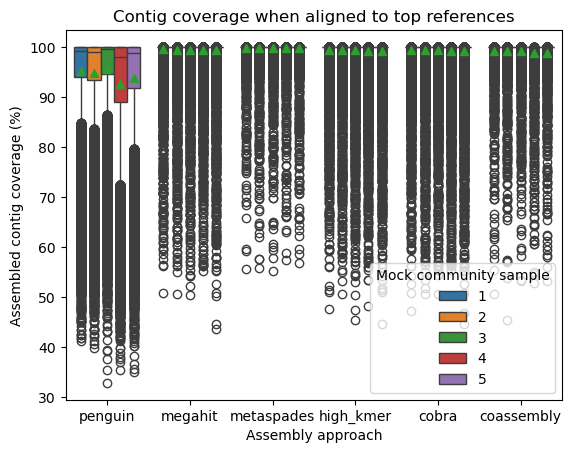

In [53]:
# plot query coverage of all contigs
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="assembler", y="qcov", hue='group', data=contig_cov_df, showmeans=True)
plt.title('Contig coverage when aligned to top references')
plt.ylabel('Assembled contig coverage (%)')
plt.xlabel('Assembly approach')
plt.legend(title='Mock community sample', loc='lower right')
plt.show()

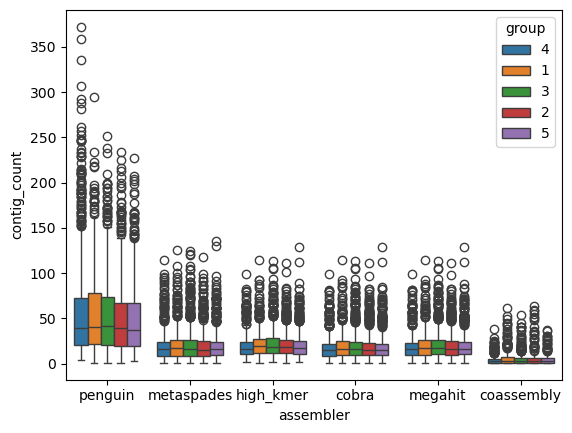

In [10]:
# plot number of contigs per reference genome
import matplotlib.pyplot as plt
import seaborn as sns

contigs_per_ref = (
    contig_cov_df
        .group_by(['tname', 'assembler', 'group'])
        .agg(pl.count('qname').alias('contig_count'))
        .sort('contig_count', descending=True)
)

sns.boxplot(x="assembler", y="contig_count", hue='group', data=contigs_per_ref)
plt.show()

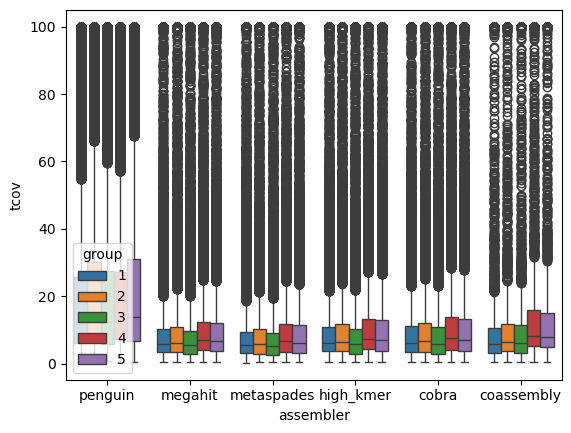

In [11]:
# plot coverage of all input genomes
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="assembler", y="tcov", hue='group', data=contig_cov_df)
plt.show()

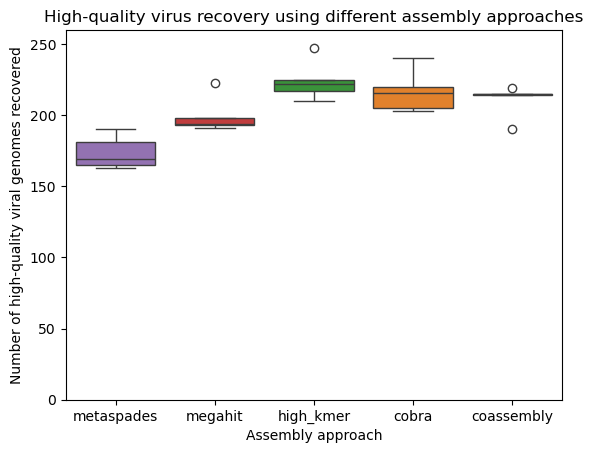

In [49]:
# plot count of hq, mq, and lq genomes
import matplotlib.pyplot as plt
import seaborn as sns

hq_count = contig_cov_df.filter(pl.col('tcov') >= 90).unique(['tname', 'assembler']).group_by('assembler', 'group').len().with_columns(pl.lit('hq').alias('quality'))
mq_count = contig_cov_df.filter((pl.col('tcov') >= 50) & (pl.col('tcov') < 90)).unique(['tname', 'assembler']).group_by('assembler', 'group').len().with_columns(pl.lit('mq').alias('quality'))
lq_count = contig_cov_df.filter(pl.col('tcov') < 50).unique(['tname', 'assembler']).group_by('assembler', 'group').len().with_columns(pl.lit('lq').alias('quality'))
contig_quality_counts = pl.concat([hq_count,])# mq_count, lq_count])

# plt.figure(figsize=(12, 6))
sns.boxplot(x="assembler", y="len", data=contig_quality_counts.filter(pl.col('assembler') != 'penguin'), hue='assembler', order=['metaspades', 'megahit', 'high_kmer', 'cobra', 'coassembly'])
# plt.yscale('log')
plt.ylim(0, 260)
plt.title('High-quality virus recovery using different assembly approaches')
plt.ylabel('Number of high-quality viral genomes recovered')
plt.xlabel('Assembly approach')
plt.show()

In [25]:
# genomes recovered via single and coassembly
# genomes recovered via single assembly only
# genomes recovered via coassembly only

coassemblies = (
    contig_cov_df
        .filter(
            (pl.col('tcov') >= 90) &
            (pl.col('pid') >= 95) &
            (pl.col('assembler') != 'penguin')
        )
        .group_by(pl.col('tname', 'assembler'))
        .first()
        .group_by(pl.col('tname'))
        .agg([pl.col('assembler')])
        .filter(pl.col('assembler').list.contains('coassembly'))
)

megahit = (
    contig_cov_df
        .filter(
            (pl.col('tcov') >= 90) &
            (pl.col('pid') >= 95) &
            (pl.col('assembler') != 'penguin')
        )
        .group_by(pl.col('tname', 'assembler'))
        .first()
        .group_by(pl.col('tname'))
        .agg([pl.col('assembler')])
        .filter(pl.col('assembler').list.contains('megahit'))
)

high_kmer = (
    contig_cov_df
        .filter(
            (pl.col('tcov') >= 90) &
            (pl.col('pid') >= 95) &
            (pl.col('assembler') != 'penguin')
        )
        .group_by(pl.col('tname', 'assembler'))
        .first()
        .group_by(pl.col('tname'))
        .agg([pl.col('assembler')])
        .filter(pl.col('assembler').list.contains('high_kmer'))
)

cobra = (
    contig_cov_df
        .filter(
            (pl.col('tcov') >= 90) &
            (pl.col('pid') >= 95) &
            (pl.col('assembler') != 'penguin')
        )
        .group_by(pl.col('tname', 'assembler'))
        .first()
        .group_by(pl.col('tname'))
        .agg([pl.col('assembler')])
        .filter(pl.col('assembler').list.contains('cobra'))
)

In [26]:
print("Number HQ in standard & high-kmer:", high_kmer.filter(pl.col('tname').is_in(megahit['tname'])).unique('tname').shape[0])
print("Number HQ in high-kmer only:", high_kmer.filter(~pl.col('tname').is_in(megahit['tname'])).unique('tname').shape[0])
print("Number HQ in standard only:", megahit.filter(~pl.col('tname').is_in(high_kmer['tname'])).unique('tname').shape[0])
# this is justification to use high-kmer in the future

Number HQ in standard & high-kmer: 995
Number HQ in high-kmer only: 123
Number HQ in standard only: 4


In [27]:
print("Number HQ in standard & cobra:", cobra.filter(pl.col('tname').is_in(megahit['tname'])).unique('tname').shape[0])
print("Number HQ in cobra only:", cobra.filter(~pl.col('tname').is_in(megahit['tname'])).unique('tname').shape[0])
print("Number HQ in standard only:", megahit.filter(~pl.col('tname').is_in(cobra['tname'])).unique('tname').shape[0])

Number HQ in standard & cobra: 999
Number HQ in cobra only: 84
Number HQ in standard only: 0


In [28]:
print("Number HQ in high_kmer & cobra:", cobra.filter(pl.col('tname').is_in(high_kmer['tname'])).unique('tname').shape[0])
print("Number HQ in cobra only:", cobra.filter(~pl.col('tname').is_in(high_kmer['tname'])).unique('tname').shape[0])
print("Number HQ in high_kmer only:", high_kmer.filter(~pl.col('tname').is_in(cobra['tname'])).unique('tname').shape[0])

Number HQ in high_kmer & cobra: 1054
Number HQ in cobra only: 29
Number HQ in high_kmer only: 64


In [21]:
print("Number HQ in single & coassembly:", coassemblies.filter(pl.col('tname').is_in(megahit['tname'])).unique('tname').shape[0])
print("Number HQ in coassembly only:", coassemblies.filter(~pl.col('tname').is_in(megahit['tname'])).unique('tname').shape[0])
print("Number HQ in single assembly only:", megahit.filter(~pl.col('tname').is_in(coassemblies['tname'])).unique('tname').shape[0])
# this is justification to use individual and coassemblies in the future

Number HQ in single & coassembly: 807
Number HQ in coassembly only: 245
Number HQ in single assembly only: 192
